# Notebook Objective

# 08 Uncertainty Estimation with Conformal Prediction

This notebook extends the RUL prediction pipeline from point estimates to uncertainty-aware prediction intervals using conformal prediction.

The main objectives are:

- recreate the preprocessing and feature engineering workflow
- train the selected best-performing RUL model
- use validation residuals to construct conformal prediction intervals
- evaluate empirical interval coverage
- generate uncertainty-aware RUL intervals for test engines
- compare point-estimate and interval-based maintenance decisions

This notebook focuses on uncertainty estimation and decision support. It does not introduce new model architectures.

Conformal prediction provides distribution-free prediction intervals under exchangeability assumptions. In this notebook, it is used as a practical method to quantify uncertainty around RUL point predictions.

# Imports and Project Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from src.data_loading import DATASET_IDS
from src.config import load_config, flatten_config
from src.pipeline import recreate_prediction_pipeline
from src.models import build_xgboost_model


# Recreate Prediction Pipeline

The preprocessing, feature engineering and XGBoost prediction pipeline is recreated to obtain training, validation and test feature matrices. The validation set is used for conformal calibration.

In [3]:
config = load_config()
flat_config = flatten_config(config)

CURRENT_DATASET = flat_config["CURRENT_DATASET"]
RUL_CAP = flat_config["RUL_CAP"]
VALIDATION_SIZE = flat_config["VALIDATION_SIZE"]
RANDOM_STATE = flat_config["RANDOM_STATE"]
WINDOW_SIZE = flat_config["WINDOW_SIZE"]
WINDOW_STEP = flat_config["WINDOW_STEP"]

index_cols = flat_config["INDEX_COLS"]
target_cols = flat_config["TARGET_COLS"]
helper_cols = flat_config["HELPER_COLS"]
target_col = flat_config["TARGET_COL"]

model_config = config["models"]
conformal_config = config["conformal"]
simulation_config = config["simulation"]

if CURRENT_DATASET not in DATASET_IDS:
    raise ValueError(f"Unknown dataset: {CURRENT_DATASET}")

In [4]:
# Recreate the configured preprocessing and feature engineering pipeline.
pipeline_outputs = recreate_prediction_pipeline(config)
globals().update(pipeline_outputs)


In [5]:
# Train the selected RUL model.
xgb_model = build_xgboost_model(
    model_config,
    random_state=RANDOM_STATE
)

xgb_model.fit(
    X_train_tabular,
    y_train_tabular
)

# Generate validation predictions for conformal calibration.
y_val_pred = xgb_model.predict(X_val_tabular)

In [6]:
print(f"Current dataset: {CURRENT_DATASET}")
print(f"Training tabular shape:   {X_train_tabular.shape}")
print(f"Validation tabular shape: {X_val_tabular.shape}")
print(f"Test tabular shape:       {X_test_tabular.shape}")

print(f"Validation MAE:  {mean_absolute_error(y_val_tabular, y_val_pred):.2f}")
print(f"Validation RMSE: {root_mean_squared_error(y_val_tabular, y_val_pred):.2f}")

Current dataset: FD001
Training tabular shape:   (14241, 102)
Validation tabular shape: (3490, 102)
Test tabular shape:       (10196, 102)
Validation MAE:  9.31
Validation RMSE: 12.67


In [7]:
# Ensure that every validation sample has one prediction.
assert y_val_pred.shape[0] == y_val_tabular.shape[0]

# Ensure that validation predictions are finite numeric values.
assert np.isfinite(y_val_pred).all()

# Ensure that train and validation engines are disjoint.
assert set(train_engines).isdisjoint(set(val_engines))

# Calibration Set Preparation

The validation set is used as calibration data for conformal prediction. Absolute validation residuals are computed and later used to construct prediction intervals around point predictions.

In [8]:
# Build a calibration dataframe with validation predictions and residuals.
calibration_df = val_window_metadata.copy()
calibration_df["true_RUL"] = y_val_tabular.values
calibration_df["predicted_RUL"] = y_val_pred
calibration_df["residual"] = (
    calibration_df["true_RUL"]
    - calibration_df["predicted_RUL"]
)
calibration_df["absolute_error"] = calibration_df["residual"].abs()

calibration_df.head()

,engine,start_cycle,end_cycle,true_RUL,predicted_RUL,residual,absolute_error
0,1,1.0,30.0,125,122.004341,2.995659,2.995659
1,1,2.0,31.0,125,120.672974,4.327026,4.327026
2,1,3.0,32.0,125,119.154335,5.845665,5.845665
3,1,4.0,33.0,125,116.037529,8.962471,8.962471
4,1,5.0,34.0,125,113.166229,11.833771,11.833771


In [9]:
# Ensure that calibration metadata and validation targets are aligned.
assert calibration_df.shape[0] == y_val_tabular.shape[0]

# Ensure that all calibration absolute errors are non-negative.
assert (calibration_df["absolute_error"] >= 0).all()

# Ensure that all calibration predictions are finite numeric values.
assert np.isfinite(calibration_df["predicted_RUL"]).all()

In [10]:
calibration_df[["residual", "absolute_error"]].describe()

,residual,absolute_error
count,3490.000000,3490.000000
mean,-0.006194,9.306013
std,12.670998,8.598112
min,-53.043030,0.001530
25%,-5.765747,2.960675
50%,0.712217,6.543825
75%,7.069079,13.388671
max,44.672585,53.043030


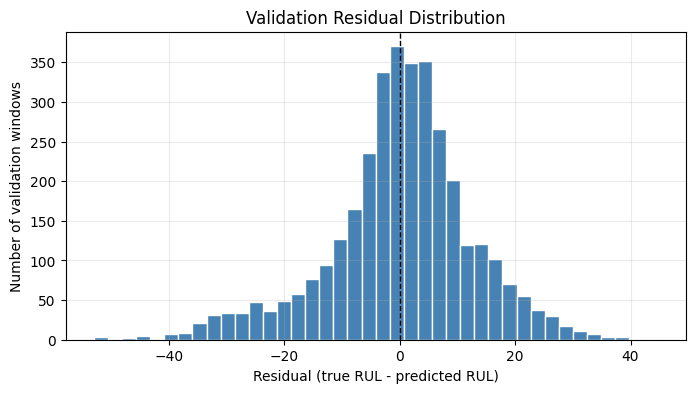

In [11]:
plt.figure(figsize=(8, 4))

plt.hist(
    calibration_df["residual"],
    bins=40,
    color="steelblue",
    edgecolor="white"
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Residual (true RUL - predicted RUL)")
plt.ylabel("Number of validation windows")
plt.title("Validation Residual Distribution")
plt.grid(True, alpha=0.25)

plt.show()

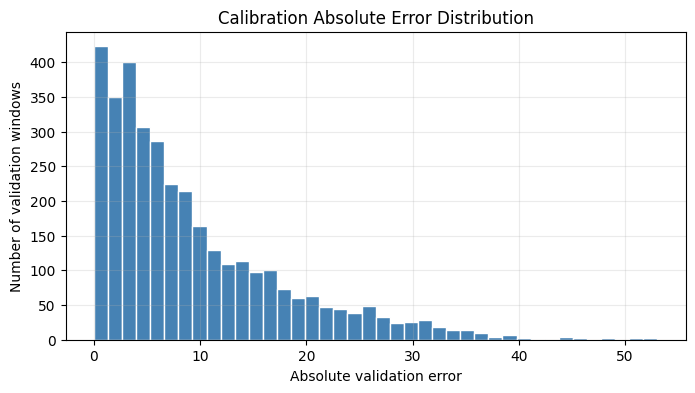

In [12]:
plt.figure(figsize=(8, 4))

plt.hist(
    calibration_df["absolute_error"],
    bins=40,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Absolute validation error")
plt.ylabel("Number of validation windows")
plt.title("Calibration Absolute Error Distribution")
plt.grid(True, alpha=0.25)

plt.show()

The calibration residuals quantify how far the model's validation predictions deviate from the true capped RUL values. The absolute errors are used as nonconformity scores for split conformal prediction. Larger calibration errors lead to wider prediction intervals.

# Conformal Prediction Interval Construction

A split conformal prediction interval is constructed from the empirical distribution of absolute calibration errors. For a desired coverage level, the corresponding error quantile is used as a symmetric interval radius around the point prediction.

In [13]:
# Define the desired marginal coverage level for conformal intervals.
COVERAGE_LEVEL = 0.90
ALPHA = 1 - COVERAGE_LEVEL

COVERAGE_LEVEL, ALPHA

(0.9, 0.09999999999999998)

In [14]:
# Compute the finite-sample conformal quantile.
calibration_errors = calibration_df["absolute_error"].to_numpy()
n_calibration = len(calibration_errors)

quantile_level = np.ceil((n_calibration + 1) * (1 - ALPHA)) / n_calibration
quantile_level = min(quantile_level, 1.0)

q_hat = np.quantile(
    calibration_errors,
    quantile_level,
    method="higher"
)

print(f"Calibration samples: {n_calibration}")
print(f"Desired coverage:    {COVERAGE_LEVEL:.2f}")
print(f"Quantile level:      {quantile_level:.4f}")
print(f"q_hat:               {q_hat:.2f}")

Calibration samples: 3490
Desired coverage:    0.90
Quantile level:      0.9003
q_hat:               22.02


In [15]:
# Ensure that the coverage level is between 0 and 1.
assert 0 < COVERAGE_LEVEL < 1

# Ensure that the conformal alpha level is between 0 and 1.
assert 0 < ALPHA < 1

# Ensure that the conformal interval radius is non-negative.
assert q_hat >= 0

In [16]:
def add_conformal_intervals(
    df,
    prediction_col,
    q_hat,
    lower_col="RUL_lower",
    upper_col="RUL_upper",
    min_value=0,
    max_value=None
):
    df = df.copy()
    
    df[lower_col] = df[prediction_col] - q_hat
    df[upper_col] = df[prediction_col] + q_hat
    
    if min_value is not None:
        df[lower_col] = df[lower_col].clip(lower=min_value)
    
    if max_value is not None:
        df[upper_col] = df[upper_col].clip(upper=max_value)
    
    return df

In [17]:
validation_interval_df = add_conformal_intervals(
    calibration_df,
    prediction_col="predicted_RUL",
    q_hat=q_hat,
    lower_col="RUL_lower",
    upper_col="RUL_upper",
    min_value=0,
    max_value=RUL_CAP
)

validation_interval_df.head()

,engine,start_cycle,end_cycle,true_RUL,predicted_RUL,residual,absolute_error,RUL_lower,RUL_upper
0,1,1.0,30.0,125,122.004341,2.995659,2.995659,99.982491,125.0
1,1,2.0,31.0,125,120.672974,4.327026,4.327026,98.651123,125.0
2,1,3.0,32.0,125,119.154335,5.845665,5.845665,97.132484,125.0
3,1,4.0,33.0,125,116.037529,8.962471,8.962471,94.015678,125.0
4,1,5.0,34.0,125,113.166229,11.833771,11.833771,91.144379,125.0


In [18]:
# Ensure that every conformal interval has a lower bound less than or equal to the upper bound.
assert (
    validation_interval_df["RUL_lower"]
    <= validation_interval_df["RUL_upper"]
).all()

# Ensure that conformal interval lower bounds are non-negative after clipping.
assert (validation_interval_df["RUL_lower"] >= 0).all()

# Ensure that conformal interval upper bounds do not exceed the RUL cap after clipping.
assert (validation_interval_df["RUL_upper"] <= RUL_CAP).all()

The conformal interval radius `q_hat` is derived from validation errors. Larger validation errors result in wider prediction intervals. Since the model predicts `RUL_capped`, interval bounds are clipped to the range `[0, RUL_CAP]`.

# Validation Coverage Analysis

The empirical coverage of the conformal intervals is evaluated on the validation data. Coverage measures the fraction of true RUL values that fall within the predicted interval.

In [19]:
# Check whether each true validation RUL lies inside its conformal interval.
validation_interval_df["covered"] = (
    (validation_interval_df["true_RUL"] >= validation_interval_df["RUL_lower"])
    & (validation_interval_df["true_RUL"] <= validation_interval_df["RUL_upper"])
)

validation_coverage = validation_interval_df["covered"].mean()

validation_interval_df["interval_width"] = (
    validation_interval_df["RUL_upper"]
    - validation_interval_df["RUL_lower"]
)

mean_interval_width = validation_interval_df["interval_width"].mean()

print(f"Target coverage:      {COVERAGE_LEVEL:.2f}")
print(f"Empirical coverage:   {validation_coverage:.3f}")
print(f"Mean interval width:  {mean_interval_width:.2f}")

Target coverage:      0.90
Empirical coverage:   0.901
Mean interval width:  37.13


In [20]:
# Ensure that empirical coverage is a valid probability.
assert 0 <= validation_coverage <= 1

# Ensure that interval widths are non-negative.
assert (validation_interval_df["interval_width"] >= 0).all()

In [21]:
# Group validation samples into RUL bins to inspect coverage across lifecycle stages.
validation_interval_df["RUL_bin"] = pd.cut(
    validation_interval_df["true_RUL"],
    bins=[0, 25, 50, 75, 100, RUL_CAP],
    include_lowest=True
)

coverage_by_rul_bin = (
    validation_interval_df
    .groupby("RUL_bin", observed=True)
    .agg(
        samples=("covered", "size"),
        coverage=("covered", "mean"),
        mean_interval_width=("interval_width", "mean"),
        mean_true_RUL=("true_RUL", "mean")
    )
    .reset_index()
)

coverage_by_rul_bin

,RUL_bin,samples,coverage,mean_interval_width,mean_true_RUL
0,"(-0.001, 25.0]",520,1.000000,35.420639,12.500000
1,"(25.0, 50.0]",500,0.952000,44.007374,38.000000
2,"(50.0, 75.0]",500,0.800000,43.591022,63.000000
3,"(75.0, 100.0]",500,0.750000,41.113567,88.000000
4,"(100.0, 125.0]",1470,0.933333,31.839443,121.047619


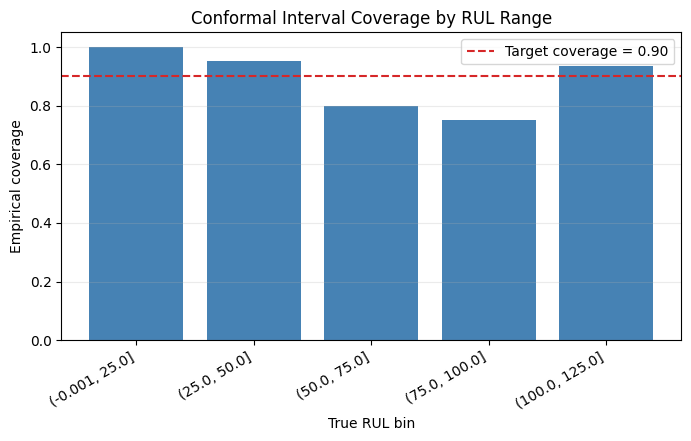

In [22]:
# Plot coverage in RUL bins
plt.figure(figsize=(8, 4))

plt.bar(
    coverage_by_rul_bin["RUL_bin"].astype(str),
    coverage_by_rul_bin["coverage"],
    color="steelblue"
)

plt.axhline(
    COVERAGE_LEVEL,
    color="tab:red",
    linestyle="--",
    label=f"Target coverage = {COVERAGE_LEVEL:.2f}"
)

plt.xlabel("True RUL bin")
plt.ylabel("Empirical coverage")
plt.title("Conformal Interval Coverage by RUL Range")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.show()

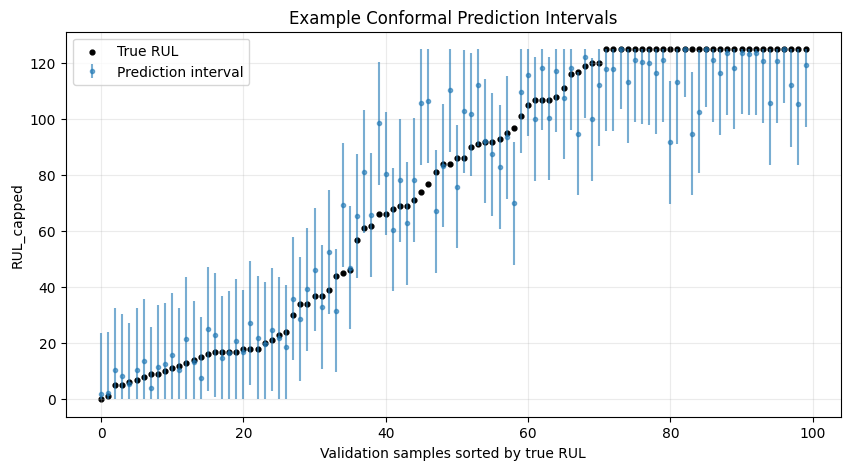

In [23]:
# Visualize a random subset of validation prediction intervals.
interval_plot_sample = validation_interval_df.sample(
    n=min(100, len(validation_interval_df)),
    random_state=RANDOM_STATE
).sort_values("true_RUL").reset_index(drop=True)

# Clip the point prediction to the same valid RUL range as the interval.
interval_plot_sample["predicted_RUL_clipped"] = interval_plot_sample["predicted_RUL"].clip(
    lower=0,
    upper=RUL_CAP
)

lower_error = (
    interval_plot_sample["predicted_RUL_clipped"]
    - interval_plot_sample["RUL_lower"]
).clip(lower=0)

upper_error = (
    interval_plot_sample["RUL_upper"]
    - interval_plot_sample["predicted_RUL_clipped"]
).clip(lower=0)

plt.figure(figsize=(10, 5))

plt.errorbar(
    x=np.arange(len(interval_plot_sample)),
    y=interval_plot_sample["predicted_RUL_clipped"],
    yerr=[lower_error, upper_error],
    fmt="o",
    markersize=3,
    alpha=0.6,
    label="Prediction interval"
)

plt.scatter(
    np.arange(len(interval_plot_sample)),
    interval_plot_sample["true_RUL"],
    color="black",
    s=12,
    label="True RUL"
)

plt.xlabel("Validation samples sorted by true RUL")
plt.ylabel("RUL_capped")
plt.title("Example Conformal Prediction Intervals")
plt.legend()
plt.grid(True, alpha=0.25)

plt.show()

The empirical validation coverage indicates how often the conformal intervals contain the true capped RUL values. Coverage by RUL range helps identify whether the interval reliability changes across different lifecycle stages. The interval width reflects the uncertainty implied by the calibration errors.

# Test Prediction Intervals

Conformal prediction intervals are generated for the test windows. For final test-level evaluation, only the last window of each test engine is used because the official RUL labels correspond to the final observed cycle.

In [24]:
# Generate point predictions for all test windows.
test_interval_df = test_window_metadata.copy()
test_interval_df["predicted_RUL"] = xgb_model.predict(X_test_tabular)

# Add conformal prediction intervals around the test point predictions.
test_interval_df = add_conformal_intervals(
    test_interval_df,
    prediction_col="predicted_RUL",
    q_hat=q_hat,
    lower_col="RUL_lower",
    upper_col="RUL_upper",
    min_value=0,
    max_value=RUL_CAP
)

test_interval_df.head()

,engine,start_cycle,end_cycle,predicted_RUL,RUL_lower,RUL_upper
0,1,1.0,30.0,107.354034,85.332184,125.0
1,1,2.0,31.0,105.240509,83.218658,125.0
2,2,1.0,30.0,116.817451,94.795601,125.0
3,2,2.0,31.0,113.653427,91.631577,125.0
4,2,3.0,32.0,104.748955,82.727104,125.0


In [25]:
# Ensure that every test window has one point prediction.
assert test_interval_df.shape[0] == X_test_tabular.shape[0]

# Ensure that every test interval has lower bound less than or equal to upper bound.
assert (
    test_interval_df["RUL_lower"]
    <= test_interval_df["RUL_upper"]
).all()

# Ensure that all test interval lower bounds are non-negative.
assert (test_interval_df["RUL_lower"] >= 0).all()

# Ensure that all test interval upper bounds do not exceed the capped RUL range.
assert (test_interval_df["RUL_upper"] <= RUL_CAP).all()

In [26]:
# Select the last available prediction interval for each test engine.
test_last_interval_df = (
    test_interval_df
    .sort_values(["engine", "end_cycle"])
    .groupby("engine")
    .tail(1)
    .reset_index(drop=True)
)

test_last_interval_df.head()

,engine,start_cycle,end_cycle,predicted_RUL,RUL_lower,RUL_upper
0,1,2.0,31.0,105.240509,83.218658,125.000000
1,2,20.0,49.0,119.407448,97.385597,125.000000
2,3,97.0,126.0,37.500763,15.478912,59.522614
3,4,77.0,106.0,92.416725,70.394875,114.438576
4,5,69.0,98.0,97.326164,75.304314,119.348015


In [27]:
# Join final test prediction intervals with the true test RUL values.
test_interval_evaluation_df = test_last_interval_df.merge(
    df_test_rul_summary,
    on="engine",
    how="left"
)

test_interval_evaluation_df = test_interval_evaluation_df.rename(columns={
    "RUL": "true_RUL"
})

test_interval_evaluation_df.head()

,engine,start_cycle,end_cycle,predicted_RUL,RUL_lower,RUL_upper,last_observed_cycle,true_RUL,estimated_failure_cycle
0,1,2.0,31.0,105.240509,83.218658,125.000000,31,112,143
1,2,20.0,49.0,119.407448,97.385597,125.000000,49,98,147
2,3,97.0,126.0,37.500763,15.478912,59.522614,126,69,195
3,4,77.0,106.0,92.416725,70.394875,114.438576,106,82,188
4,5,69.0,98.0,97.326164,75.304314,119.348015,98,91,189


In [28]:
# Ensure that the final interval table contains one row per test engine.
assert test_interval_evaluation_df["engine"].nunique() == df_test_raw["engine"].nunique()

# Ensure that selected final windows end at the last observed cycle.
assert (
    test_interval_evaluation_df["end_cycle"]
    == test_interval_evaluation_df["last_observed_cycle"]
).all()

# Ensure that every final test interval has a true RUL value.
assert test_interval_evaluation_df["true_RUL"].notna().all()

In [29]:
# Use capped true RUL for interval evaluation because the model predicts RUL_capped.
test_interval_evaluation_df["true_RUL_capped"] = (
    test_interval_evaluation_df["true_RUL"]
    .clip(upper=RUL_CAP)
)

test_interval_evaluation_df["covered"] = (
    (test_interval_evaluation_df["true_RUL_capped"] >= test_interval_evaluation_df["RUL_lower"])
    & (test_interval_evaluation_df["true_RUL_capped"] <= test_interval_evaluation_df["RUL_upper"])
)

test_interval_evaluation_df["interval_width"] = (
    test_interval_evaluation_df["RUL_upper"]
    - test_interval_evaluation_df["RUL_lower"]
)

test_coverage = test_interval_evaluation_df["covered"].mean()
test_mean_interval_width = test_interval_evaluation_df["interval_width"].mean()

print(f"Target coverage:      {COVERAGE_LEVEL:.2f}")
print(f"Test coverage:        {test_coverage:.3f}")
print(f"Mean interval width:  {test_mean_interval_width:.2f}")

Target coverage:      0.90
Test coverage:        0.930
Mean interval width:  38.76


The conformal prediction intervals achieve an empirical test coverage of 0.93, which is slightly above the target coverage of 0.90. This means that the intervals contain the true capped RUL values for 93% of the test engines.

The mean interval width is 38.76 cycles. This indicates that the uncertainty intervals are relatively wide, but they provide reliable coverage under the selected conformal calibration setup.

Since the model predicts `RUL_capped`, coverage is evaluated against capped test RUL values. The result suggests that conformal prediction provides a useful uncertainty-aware extension of the point prediction model.

In [30]:
# Ensure that test coverage is a valid probability.
assert 0 <= test_coverage <= 1

# Ensure that all final test interval widths are non-negative.
assert (test_interval_evaluation_df["interval_width"] >= 0).all()

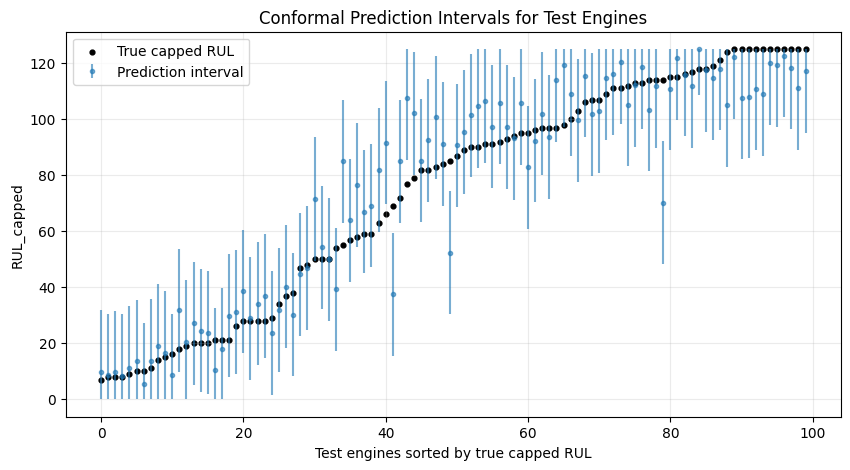

In [31]:
# Visualize final test prediction intervals sorted by true capped RUL.
test_interval_plot_df = (
    test_interval_evaluation_df
    .sort_values("true_RUL_capped")
    .reset_index(drop=True)
)

test_interval_plot_df["predicted_RUL_clipped"] = (
    test_interval_plot_df["predicted_RUL"]
    .clip(lower=0, upper=RUL_CAP)
)

lower_error = (
    test_interval_plot_df["predicted_RUL_clipped"]
    - test_interval_plot_df["RUL_lower"]
).clip(lower=0)

upper_error = (
    test_interval_plot_df["RUL_upper"]
    - test_interval_plot_df["predicted_RUL_clipped"]
).clip(lower=0)

plt.figure(figsize=(10, 5))

plt.errorbar(
    x=np.arange(len(test_interval_plot_df)),
    y=test_interval_plot_df["predicted_RUL_clipped"],
    yerr=[lower_error, upper_error],
    fmt="o",
    markersize=3,
    alpha=0.6,
    label="Prediction interval"
)

plt.scatter(
    np.arange(len(test_interval_plot_df)),
    test_interval_plot_df["true_RUL_capped"],
    color="black",
    s=12,
    label="True capped RUL"
)

plt.xlabel("Test engines sorted by true capped RUL")
plt.ylabel("RUL_capped")
plt.title("Conformal Prediction Intervals for Test Engines")
plt.legend()
plt.grid(True, alpha=0.25)

plt.show()

The test prediction intervals provide uncertainty-aware RUL estimates for the final observed cycle of each test engine. Since the model was trained on `RUL_capped`, interval coverage is evaluated against capped test RUL values. The empirical test coverage indicates how often the conformal intervals contain the true capped RUL.

# Uncertainty-Aware Maintenance Decisions

Conformal prediction intervals can be used to define uncertainty-aware maintenance policies. Instead of relying only on the point estimate, maintenance can be triggered when the lower prediction bound falls below a decision threshold.

In [32]:
UNCERTAINTY_AWARE_THRESHOLD = 20

In [33]:
# Build an engine-level table with point predictions and conformal intervals.
uncertainty_maintenance_df = test_interval_evaluation_df[[
    "engine",
    "last_observed_cycle",
    "true_RUL",
    "true_RUL_capped",
    "predicted_RUL",
    "RUL_lower",
    "RUL_upper"
]].copy()

uncertainty_maintenance_df.head()

,engine,last_observed_cycle,true_RUL,true_RUL_capped,predicted_RUL,RUL_lower,RUL_upper
0,1,31,112,112,105.240509,83.218658,125.000000
1,2,49,98,98,119.407448,97.385597,125.000000
2,3,126,69,69,37.500763,15.478912,59.522614
3,4,106,82,82,92.416725,70.394875,114.438576
4,5,98,91,91,97.326164,75.304314,119.348015


In [34]:
# Trigger maintenance based on the point estimate.
uncertainty_maintenance_df["point_policy_maintenance"] = (
    uncertainty_maintenance_df["predicted_RUL"]
    <= UNCERTAINTY_AWARE_THRESHOLD
)

# Trigger maintenance based on the lower conformal bound.
uncertainty_maintenance_df["interval_policy_maintenance"] = (
    uncertainty_maintenance_df["RUL_lower"]
    <= UNCERTAINTY_AWARE_THRESHOLD
)

uncertainty_maintenance_df.head()

,engine,last_observed_cycle,true_RUL,true_RUL_capped,predicted_RUL,RUL_lower,RUL_upper,point_policy_maintenance,interval_policy_maintenance
0,1,31,112,112,105.240509,83.218658,125.000000,False,False
1,2,49,98,98,119.407448,97.385597,125.000000,False,False
2,3,126,69,69,37.500763,15.478912,59.522614,False,True
3,4,106,82,82,92.416725,70.394875,114.438576,False,False
4,5,98,91,91,97.326164,75.304314,119.348015,False,False


In [35]:
# Comparison to maintenance counts
uncertainty_policy_summary = pd.DataFrame({
    "policy": ["point_estimate", "interval_lower_bound"],
    "maintenance_triggered": [
        uncertainty_maintenance_df["point_policy_maintenance"].sum(),
        uncertainty_maintenance_df["interval_policy_maintenance"].sum(),
    ],
    "total_engines": [
        uncertainty_maintenance_df.shape[0],
        uncertainty_maintenance_df.shape[0],
    ]
})

uncertainty_policy_summary

,policy,maintenance_triggered,total_engines
0,point_estimate,13,100
1,interval_lower_bound,30,100


In [36]:
# Ensure that the uncertainty-aware threshold is non-negative.
assert UNCERTAINTY_AWARE_THRESHOLD >= 0

# Ensure that point-policy decisions are boolean values.
assert uncertainty_maintenance_df["point_policy_maintenance"].dtype == bool

# Ensure that interval-policy decisions are boolean values.
assert uncertainty_maintenance_df["interval_policy_maintenance"].dtype == bool

# Ensure that the interval policy is at least as conservative as the point policy.
assert (
    uncertainty_maintenance_df["interval_policy_maintenance"].sum()
    >= uncertainty_maintenance_df["point_policy_maintenance"].sum()
)

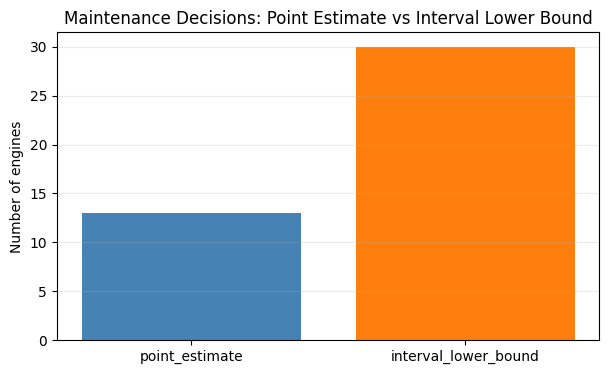

In [37]:
plt.figure(figsize=(7, 4))

plt.bar(
    uncertainty_policy_summary["policy"],
    uncertainty_policy_summary["maintenance_triggered"],
    color=["steelblue", "tab:orange"]
)

plt.ylabel("Number of engines")
plt.title("Maintenance Decisions: Point Estimate vs Interval Lower Bound")
plt.grid(axis="y", alpha=0.25)

plt.show()

In [38]:
PLANNED_MAINTENANCE_COST = 1.0
FAILURE_COST = 10.0
EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE = 0.02

In [39]:
def calculate_policy_cost_from_decision(
    true_RUL,
    maintenance_triggered,
    planned_cost=1.0,
    failure_cost=10.0,
    early_cost_per_cycle=0.02
):
    if maintenance_triggered:
        return (
            planned_cost + early_cost_per_cycle * true_RUL,
            "planned_maintenance"
        )

    return failure_cost, "failure"

In [40]:
uncertainty_maintenance_df[["point_policy_cost", "point_policy_outcome"]] = (
    uncertainty_maintenance_df
    .apply(
        lambda row: pd.Series(
            calculate_policy_cost_from_decision(
                true_RUL=row["true_RUL"],
                maintenance_triggered=row["point_policy_maintenance"],
                planned_cost=PLANNED_MAINTENANCE_COST,
                failure_cost=FAILURE_COST,
                early_cost_per_cycle=EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE
            )
        ),
        axis=1
    )
)

uncertainty_maintenance_df[["interval_policy_cost", "interval_policy_outcome"]] = (
    uncertainty_maintenance_df
    .apply(
        lambda row: pd.Series(
            calculate_policy_cost_from_decision(
                true_RUL=row["true_RUL"],
                maintenance_triggered=row["interval_policy_maintenance"],
                planned_cost=PLANNED_MAINTENANCE_COST,
                failure_cost=FAILURE_COST,
                early_cost_per_cycle=EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE
            )
        ),
        axis=1
    )
)

In [41]:
uncertainty_cost_summary = pd.DataFrame({
    "policy": ["point_estimate", "interval_lower_bound"],
    "total_cost": [
        uncertainty_maintenance_df["point_policy_cost"].sum(),
        uncertainty_maintenance_df["interval_policy_cost"].sum(),
    ],
    "mean_cost_per_engine": [
        uncertainty_maintenance_df["point_policy_cost"].mean(),
        uncertainty_maintenance_df["interval_policy_cost"].mean(),
    ],
    "failures": [
        (uncertainty_maintenance_df["point_policy_outcome"] == "failure").sum(),
        (uncertainty_maintenance_df["interval_policy_outcome"] == "failure").sum(),
    ],
    "planned_maintenance": [
        (uncertainty_maintenance_df["point_policy_outcome"] == "planned_maintenance").sum(),
        (uncertainty_maintenance_df["interval_policy_outcome"] == "planned_maintenance").sum(),
    ]
})

uncertainty_cost_summary

,policy,total_cost,mean_cost_per_engine,failures,planned_maintenance
0,point_estimate,886.16,8.8616,87,13
1,interval_lower_bound,743.50,7.4350,70,30


The uncertainty-aware interval policy reduces the simulated maintenance cost compared with the point-estimate policy.

This improvement is mainly driven by the more conservative decision rule. Instead of relying only on the predicted RUL, the interval-based policy uses the lower bound of the conformal prediction interval. As a result, maintenance is triggered earlier for more engines, which reduces the number of simulated failures.

At the same time, the interval-based policy increases the number of planned maintenance actions. This reflects the expected trade-off in uncertainty-aware predictive maintenance: accounting for uncertainty can reduce failure risk, but it may also lead to earlier interventions and potentially unused remaining lifetime.

Under the current simplified cost assumptions, the reduction in failure-related cost outweighs the additional planned maintenance cost. This suggests that conformal prediction intervals can provide useful decision support beyond point-estimate RUL predictions.

# Conformal Prediction Takeaways

This notebook extended the RUL prediction pipeline from point estimates to uncertainty-aware prediction intervals using split conformal prediction.

The conformal intervals were calibrated using validation residuals. The resulting interval width reflects the empirical prediction error of the selected XGBoost model on unseen validation trajectories.

On the test set, the conformal intervals achieved empirical coverage slightly above the desired target level. This indicates that the intervals provide a useful uncertainty-aware extension of the capped RUL point predictions.

Because the model was trained on `RUL_capped`, interval construction and coverage evaluation were performed in the capped RUL space. This means that the intervals quantify uncertainty around capped RUL predictions rather than uncapped true remaining lifetime.

The interval lower-bound policy was more conservative than the point-estimate policy. It triggered maintenance earlier for more engines, reduced simulated failures and lowered total simulated cost under the simplified cost assumptions.

The results show that uncertainty-aware RUL intervals can support maintenance decisions beyond point predictions. Instead of only asking what the predicted RUL is, the decision process can also consider how low the remaining useful life could plausibly be.

The current conformal prediction setup is intentionally simple. It uses one global calibration error quantile and symmetric intervals around point predictions. Future work could explore conditional or adaptive intervals, rolling recalibration and uncertainty-aware cost optimization.